## Disaster tweets classification.

Dataset was sourced from kaggle - https://www.kaggle.com/competitions/nlp-getting-started
This python script builds and trains a series of models to predict if a disaster occurred based on X (Twitter) tweets

The dataset is also available on Github: https://github.com/laxmimerit/twitter-disaster-prediction-dataset/tree/master

This python script is a work in progress


In [1]:
# Import Libraries
import re
import string
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

plt.style.use('ggplot')

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D, Dropout
from tensorflow.keras.optimizers import Adam

## Read in the data

In [2]:
# Below is a function to read in and create dataframes for the train and test data from my local drive.
# I have kept this code in but chose to not run it.
# I am obtaining the data from github, however, in case that data becomes unavailable, the below function is available to read in from my local drive where I have saved it
def load_from_drive():
    
    # Set the location to read the files
    base_path = "C:\\Users\\User\\Documents\\Python_Repositories\\NLP_Projects\\Disaster_Tweets\\"
    training_path = base_path + "train.csv"
    test_path = base_path + "test.csv"

    # Read in the train and test datasets and save these as dataframes
    tweet = pd.read_csv(training_path)
    tweet_test = pd.read_csv(test_path)

In [3]:
tweet = pd.read_csv('https://raw.githubusercontent.com/laxmimerit/twitter-disaster-prediction-dataset/refs/heads/master/train.csv')
tweet.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [4]:
# Check the number of rows and columns
tweet.shape

(7613, 5)

In [5]:
# Check null values
# some observations for keyword and location are missing
tweet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


## Exploratory data analysis

In [6]:
# Set default parameters for plots
plt.rcParams['figure.figsize'] = [8,4]
plt.rcParams['figure.dpi'] = 120

Target class distribution - check number of times the target was 1 (disaster) and 0 (not a disaster)

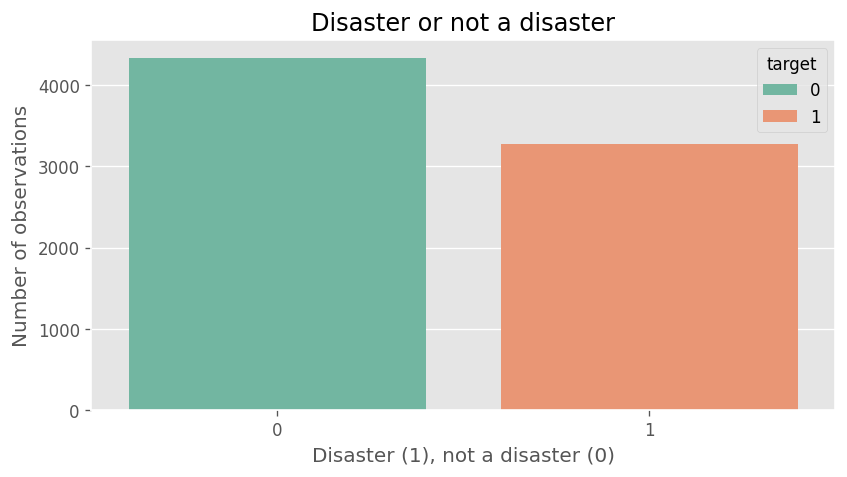

In [7]:
sns.countplot(data=tweet, x = 'target', hue = 'target', palette = "Set2")
plt.title('Disaster or not a disaster')
plt.xlabel('Disaster (1), not a disaster (0)')
plt.ylabel('Number of observations')
plt.show()

In [8]:
# Check the actual number of observations for each of the target variable
tweet['target'].value_counts()

target
0    4342
1    3271
Name: count, dtype: int64

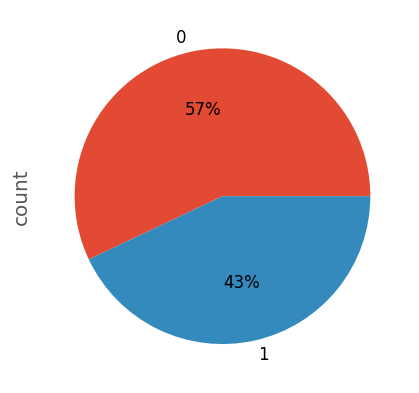

In [9]:
# Create a pie plot to check the proportion of observations in each target. Display as a percentage
tweet['target'].value_counts().plot.pie(autopct = '%1.f%%')
plt.show()

Number of characters in a tweet. Distribution in the number of characters

In [10]:
# Install pre-process package from git.
# This is available here: https://github.com/laxmimerit/preprocess_kgptalkie
!pip install git+https://github.com/laxmimerit/preprocess_kgptalkie.git

  Cloning https://github.com/laxmimerit/preprocess_kgptalkie.git to c:\users\user\appdata\local\temp\pip-req-build-29xpcfu6
  Resolved https://github.com/laxmimerit/preprocess_kgptalkie.git to commit 0f56a6502679f6750b7f0ffed98f590d1f0246bd
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/laxmimerit/preprocess_kgptalkie.git 'C:\Users\User\AppData\Local\Temp\pip-req-build-29xpcfu6'


In [11]:
import preprocess_kgptalkie as kgp

C:\Users\User\anaconda3\envs\tflowenv\lib\site-packages\torch\__init__.py:747: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at ..\torch\csrc\tensor\python_tensor.cpp:433.)
  _C._set_default_tensor_type(t)


Create a feature for the number of characters in the tweet

In [12]:
# Create a feature for character length
tweet['char_count'] = tweet['text'].apply(lambda x: len(x))

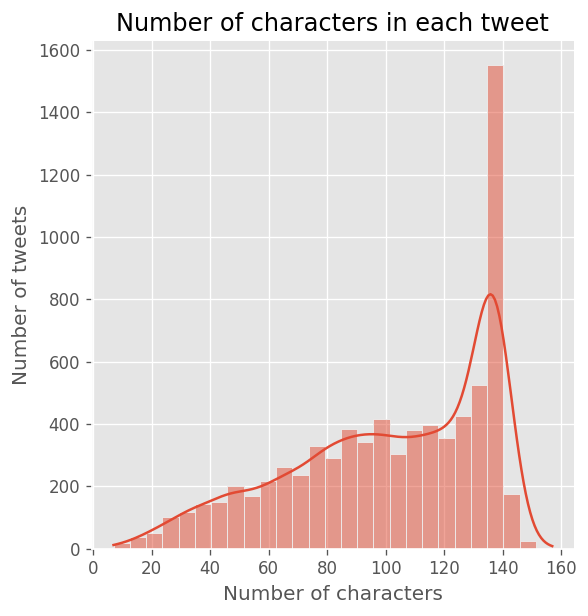

In [16]:
# plot the distribution of characters in each tweet
sns.displot(tweet['char_count'], kde=True)
plt.title('Number of characters in each tweet')
plt.xlabel('Number of characters')
plt.ylabel('Number of tweets')
plt.show()